In [6]:
# Подавление предупреждений
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

# Импорт необходимых библиотек
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import polars as pl
import pandas as pd
from collections import Counter
from torch.utils.data import TensorDataset, DataLoader
import yfinance as yf
import sklearn
import networkx as nx
import jupyterlab as jlab
import ipywidgets
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from torch import Tensor
from einops import rearrange
from typing import Tuple, Callable
from torch.autograd import Function

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D

## Домашнее задание № 6

### Домашнее задание: Обучение и визуализация Mamba

### Цель задания

1. Обучить простую модель семейства Mamba для обработки любых данных (на выбор: текст, аудио, видео, изображения и ...)
2. Визуализировать веса внимания и интерпретировать их
3. Сделать выводы о том, как модель воспринимает данные и принимает решения

Для сравнения с предыдущим ДЗ возьмём тот же датасет `emotion` с Hugging Face, который содержит тексты, классифицированные по 6 эмоциям:
- 0: _sadness_
- 1: _joy_
- 2: _love_
- 3: _anger_
- 4: _fear_
- 5: _surprise_


In [7]:
dataset = load_dataset("dair-ai/emotion")

In [8]:
print(dataset)

print("Текст:", dataset['train'][0]['text'])
print('Метка:', dataset['train'][0]['label'])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Текст: i didnt feel humiliated
Метка: 0


In [9]:
X_train = dataset['train']['text']
y_train = dataset['train']['label']

X_test = dataset['test']['text']
y_test = dataset['test']['label']

X_train = X_train[:5000]
y_train = y_train[:5000]

X_test = X_test[:1500]
y_test = y_test[:1500]

print(f"Размер трейн выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")

Размер трейн выборки: 5000
Размер тестовой выборки: 1500


In [10]:
MAX_VOCAB_SIZE = 10000
MAX_LEN = 16     
embedding_dim = 128

counter = Counter()
for text in X_train:
    counter.update(text.lower().split())

vocab = {"<PAD>": 0, "<UNK>": 1}

for word, _ in counter.most_common(MAX_VOCAB_SIZE - 2):
    vocab[word] = len(vocab)

inv_vocab = {idx: word for word, idx in vocab.items()}

def encode(text):
    tokens = text.lower().split()
    indices = [vocab.get(token, vocab["<UNK>"]) for token in tokens]

    indices = indices[:MAX_LEN]
    if len(indices) < MAX_LEN:
        indices += [vocab["<PAD>"]] * (MAX_LEN - len(indices))
    return indices

def decode(indices):
    return [inv_vocab.get(i, "<UNK>") for i in indices]

X_train_encoded = [encode(text) for text in X_train]
X_test_encoded  = [encode(text) for text in X_test]

X_train_tensor = torch.tensor(X_train_encoded, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_encoded, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

vocab_size = len(vocab)

train_data = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
test_data = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

In [11]:
class PScan(Function):
    @staticmethod
    def forward(ctx, A_inp, X_inp):
        A, X = A_inp.clone(), X_inp.clone()
        A, X = rearrange(A, "l b d s -> b d l s"), rearrange(X, "l b d s -> b d l s")
        PScan._forward(A, X)
        ctx.save_for_backward(A_inp, X)   
        return rearrange(X, "b d l s -> b l d s")

    @staticmethod
    def backward(ctx, grad_inp: Tensor) -> Tuple[Tensor, Tensor]:
        A_inp, X = ctx.saved_tensors
        A = rearrange(A_inp.clone(), "l b d s -> b d l s")
        A = torch.cat((A[:, :, :1], A[:, :, 1:].flip(2)), dim=2)
        grad_out = rearrange(grad_inp, "b l d s -> b d l s")
        grad_out = grad_out.flip(2)
        PScan._forward(A, grad_out)
        grad_out = grad_out.flip(2)
        Q = torch.zeros_like(X)
        Q[:, :, 1:].add_(X[:, :, :-1] * grad_out[:, :, 1:])
        return rearrange(Q, "b d l s -> l b d s"), rearrange(grad_out, "b d l s -> l b d s")

    @staticmethod
    def _forward(A: Tensor, X: Tensor) -> None:
        b, d, l, s = A.shape
        num_steps = int(math.log2(l))
        Av, Xv = A, X
        for _ in range(num_steps):
            T = Xv.size(2)
            Av, Xv = Av[:, :, :T].reshape(b, d, T // 2, 2, -1), Xv[:, :, :T].reshape(b, d, T // 2, 2, -1)
            Xv[:, :, :, 1].add_(Av[:, :, :, 1].mul(Xv[:, :, :, 0]))
            Av[:, :, :, 1].mul_(Av[:, :, :, 0])
            Av, Xv = Av[:, :, :, 1], Xv[:, :, :, 1]
        for k in range(num_steps - 1, -1, -1):
            Av, Xv = A[:, :, 2**k - 1 : l : 2**k], X[:, :, 2**k - 1 : l : 2**k]
            T = 2 * (Xv.size(2) // 2)
            if T < Xv.size(2):
                Xv[:, :, -1].add_(Av[:, :, -1].mul(Xv[:, :, -2]))
                Av[:, :, -1].mul_(Av[:, :, -2])
            Av, Xv = Av[:, :, :T].reshape(b, d, T // 2, 2, -1), Xv[:, :, :T].reshape(b, d, T // 2, 2, -1)
            Xv[:, :, 1:, 0].add_(Av[:, :, 1:, 0].mul(Xv[:, :, :-1, 1]))
            Av[:, :, 1:, 0].mul_(Av[:, :, :-1, 1])

pscan: Callable[[Tensor, Tensor], Tensor] = PScan.apply


class RMSNorm(nn.Module):
    def __init__(self, d_model: int, eps: float = 1e-8) -> None:
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x: Tensor) -> Tensor:
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight


class MambaBlock(nn.Module):
    def __init__(self, d_input, d_model, d_state=16, dt_rank=None):
        super(MambaBlock, self).__init__()
        dt_rank = dt_rank or max(d_model // 16, 4)

        self.norm = RMSNorm(d_input)
        self.in_proj = nn.Linear(d_input, d_model)
        self.s_B = nn.Linear(d_model, d_state)       
        self.s_C = nn.Linear(d_model, d_state)       
        self.s_Delta = nn.Linear(d_model, dt_rank)   
        self.dt_proj = nn.Linear(dt_rank, d_model)
        self.out_proj = nn.Linear(d_model, d_input)

        A = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(d_model, 1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(d_model))
        self.last_delta = None
        self.last_attn = None
        self.record_attn = False  
    def forward(self, x):
        residual = x
        x = self.norm(x)
        x = self.in_proj(x)

        B, C = self.s_B(x), self.s_C(x)
        delta = F.softplus(self.dt_proj(self.s_Delta(x)))   

        A = -torch.exp(self.A_log)
        A_bar = torch.exp(delta.unsqueeze(-1) * A)                       
        Bx = delta.unsqueeze(-1) * B.unsqueeze(2) * x.unsqueeze(-1)      
        h = pscan(A_bar.transpose(0, 1), Bx.transpose(0, 1))            
        y = torch.einsum("blds,bls->bld", h, C) + self.D * x

        self.last_delta = delta.detach()

        if self.record_attn:
            with torch.no_grad():
                b0 = 0
                Abar0, C0, B0 = A_bar[b0], C[b0], B[b0]
                L = Abar0.shape[0]
                attn = torch.zeros(L, L)
                for t in range(L):
                    cumprod = torch.ones_like(Abar0[0])
                    for s in range(t, -1, -1):
                        attn[t, s] = (C0[t].unsqueeze(0) * cumprod * B0[s].unsqueeze(0)).sum(-1).mean()
                        cumprod = cumprod * Abar0[s]
                self.last_attn = attn

        return residual + self.out_proj(y)


class Mamba(nn.Module):
    def __init__(self, num_layers, d_input, d_model, d_state=16):
        super(Mamba, self).__init__()
        self.layers = nn.ModuleList([MambaBlock(d_input, d_model, d_state) for _ in range(num_layers)])

    def forward(self, seq):
        for mamba in self.layers:
            seq = mamba(seq)
        return seq

In [12]:
class MambaTextClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, d_input=128, d_model=128, d_state=16, num_layers=2, padding_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_input, padding_idx=padding_idx)
        self.mamba = Mamba(num_layers=num_layers, d_input=d_input, d_model=d_model, d_state=d_state)
        self.fc_out = nn.Linear(d_input, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = self.mamba(x)
        pooled = x.mean(dim=1)
        return self.fc_out(pooled)

Эпоха 1/25 , потери: 1.5544 , точность: 0.4480
Эпоха 2/25 , потери: 1.2077 , точность: 0.5953
Эпоха 3/25 , потери: 0.8486 , точность: 0.6820
Эпоха 4/25 , потери: 0.6059 , точность: 0.7020
Эпоха 5/25 , потери: 0.4809 , точность: 0.7133
Эпоха 6/25 , потери: 0.3831 , точность: 0.7273
Эпоха 7/25 , потери: 0.3211 , точность: 0.7107
Эпоха 8/25 , потери: 0.2685 , точность: 0.6973
Эпоха 9/25 , потери: 0.2041 , точность: 0.6980
Эпоха 10/25 , потери: 0.1937 , точность: 0.7073
Эпоха 11/25 , потери: 0.1722 , точность: 0.7247
Эпоха 12/25 , потери: 0.1449 , точность: 0.7000
Эпоха 13/25 , потери: 0.1499 , точность: 0.7173
Эпоха 14/25 , потери: 0.1081 , точность: 0.7040
Эпоха 15/25 , потери: 0.1401 , точность: 0.7047
Эпоха 16/25 , потери: 0.1167 , точность: 0.7013
Эпоха 17/25 , потери: 0.1425 , точность: 0.7080
Эпоха 18/25 , потери: 0.0734 , точность: 0.6727
Эпоха 19/25 , потери: 0.0798 , точность: 0.7087
Эпоха 20/25 , потери: 0.0777 , точность: 0.7040
Эпоха 21/25 , потери: 0.0831 , точность: 0.7007
Э

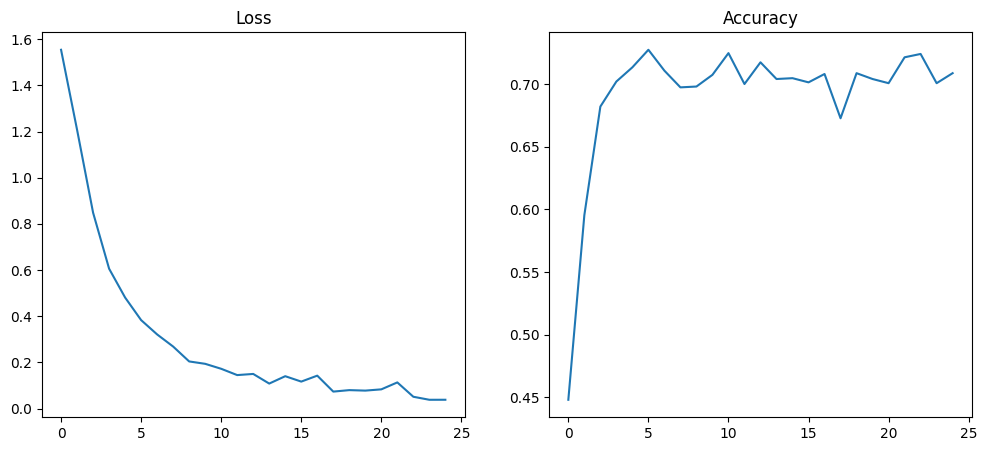

Финальная точность: 0.7086666666666667


In [13]:
model = MambaTextClassifier(vocab_size=vocab_size, num_classes=6, d_input=128, d_model=128, d_state=16, num_layers=2)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

losses = []
accuracies = []

def evaluate(model, test):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_test, y_test in test:
            X_test, y_test = X_test.to('cpu'), y_test.to('cpu')
            output = model(X_test)
            preds = output.argmax(dim=1)
            correct += (preds == y_test).sum().item()
            total += y_test.size(0)
    return correct/total


def train_with_logging(model, train, test, optimizer, criterion, epochs=10):

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for X_train, y_train in train:
            X_train, y_train = X_train.to('cpu'), y_train.to('cpu')
            optimizer.zero_grad()
            output = model(X_train)
            loss = criterion(output, y_train)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss/len(train)
        acc = evaluate(model, test)
        losses.append(avg_loss)
        accuracies.append(acc)
        print(f"Эпоха {epoch+1}/{epochs} , потери: {avg_loss:.4f} , точность: {acc:.4f}")


train_with_logging(model, train_data, test_data, optimizer, criterion, epochs=25)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(losses)
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(accuracies)
plt.title("Accuracy")

plt.show()

accuracy = evaluate(model, test_data)
print("Финальная точность:", accuracy)

2. Визуализировать веса внимания и интерпретировать их


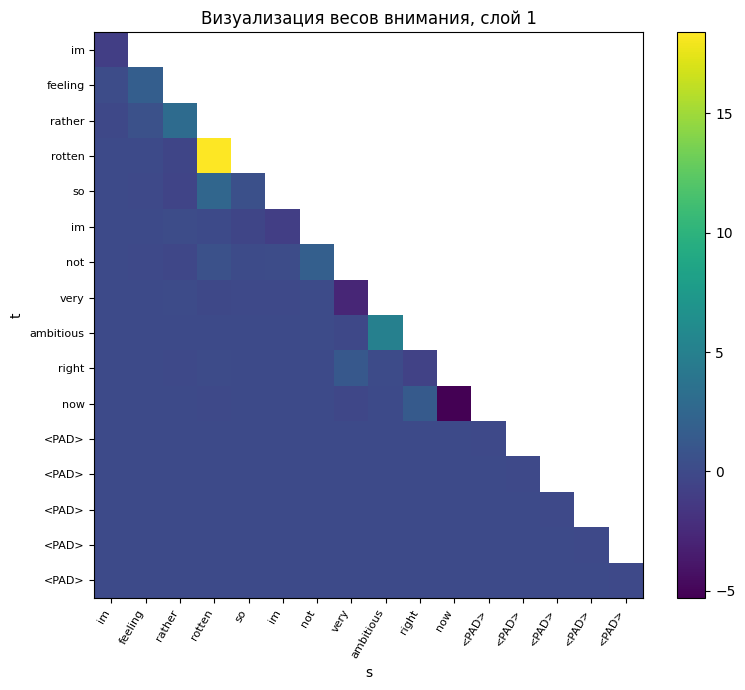

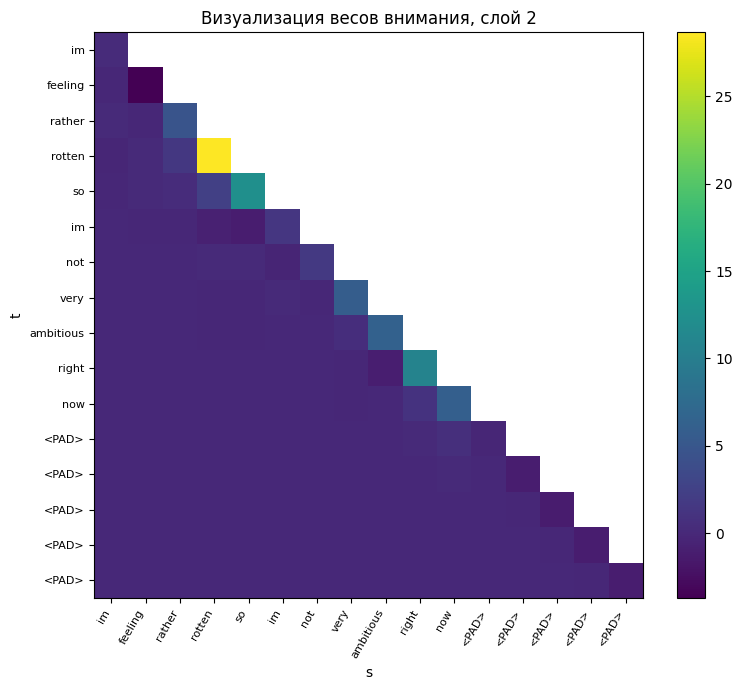

In [14]:
model.eval()
for layer in model.mamba.layers:
    layer.record_attn = True

X_example, y_example = next(iter(test_data))
with torch.no_grad():
    _ = model(X_example)

example_idx = 0
tokens = decode(X_example[example_idx].tolist())

def plot_attention(layer_idx, attn, tokens):
    attn = attn.numpy()
    mask = np.triu(np.ones_like(attn, dtype=bool), k=1)  
    attn_masked = np.where(mask, np.nan, attn)

    plt.figure(figsize=(8, 7))
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color='white')
    plt.imshow(attn_masked, cmap=cmap, aspect='auto')
    plt.colorbar()
    plt.title(f"Визуализация весов внимания, слой {layer_idx + 1}")
    plt.xlabel("s")
    plt.ylabel("t")
    plt.xticks(range(len(tokens)), tokens, rotation=60, ha='right', fontsize=8)
    plt.yticks(range(len(tokens)), tokens, fontsize=8)
    plt.tight_layout()
    plt.show()

for i, layer in enumerate(model.mamba.layers):
    plot_attention(i, layer.last_attn, tokens)

На графиках показаны веса внимания (так как модель использует только предыдущие слова, то верхняя треугольная часть матрицы пустая), из них видно, что 
что наибольшие значения находятся около главной диагонали. Это означает, что при обработке каждого слова модель в основном использует информацию из ближайших предыдущих слов. Кроме того, особенно заметны большие веса для таких слов как _rotten_, _very_, _ambitious_ и _right_. То есть эти слова являются наиболее информативными для определения эмоциональной окраски предложения.

Первый и второй слои в целом выглядят идентично, также видно, что токены <PAD> практически не оказывают влияния на содержательные слова предложения, что говорит о корректной работе модели. В целом модель уделяет основное внимание эмоционально окрашенным словам и их ближайшему контексту, что соответствует задаче классификации коротких текстов по эмоциям.

3. Сделать выводы о том, как модель воспринимает данные и принимает решения

посмотрим насколько уверенно модель принимает решения:

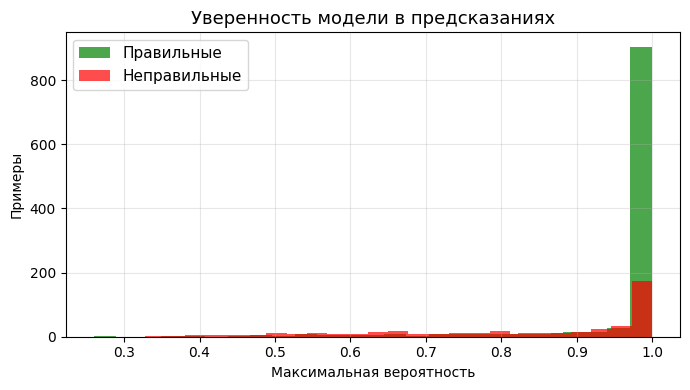

Доля высокоуверенных предсказаний: 0.794
Средняя уверенность правильных:  0.966441810131073
Средняя уверенность неправильных: 0.8428967595100403


In [15]:
all_probs = []
all_preds = []
all_true  = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_data:
        output = model(X_batch)
        probs = torch.softmax(output, dim=1)
        preds = probs.argmax(dim=1)
        all_probs.append(probs)
        all_preds.append(preds)
        all_true.append(y_batch)

all_probs = torch.cat(all_probs).numpy()
all_preds = torch.cat(all_preds).numpy()
all_true  = torch.cat(all_true).numpy()
confidence = all_probs.max(axis=1)


correct_mask = (all_preds == all_true)
plt.figure(figsize=(7, 4))
plt.hist(confidence[correct_mask],  bins=25, alpha=0.7, color='green', label='Правильные')
plt.hist(confidence[~correct_mask], bins=25, alpha=0.7, color='red',   label='Неправильные')
plt.title('Уверенность модели в предсказаниях', fontsize=13)
plt.xlabel('Максимальная вероятность')
plt.ylabel('Примеры')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Доля высокоуверенных предсказаний: {(confidence > 0.9).mean()}")
print(f"Средняя уверенность правильных:  {confidence[correct_mask].mean()}")
print(f"Средняя уверенность неправильных: {confidence[~correct_mask].mean()}")

На графике представлено распределение уверенности модели в своих предсказаниях. 

Видно, что большинство предсказаний сосредоточено в области вероятностей, близких к 1. Это говорит о высокой уверенности модели в принимаемых решениях.
При этом большая часть высокоуверенных предсказаний оказывается правильной, что свидетельствует о хорошей согласованности 
между уверенностью модели и качеством классификации. Небольшое количество ошибок при высокой уверенности все же присутствует,
что в целом ожидаемо.

И посмотрим на матрицу ошибок:

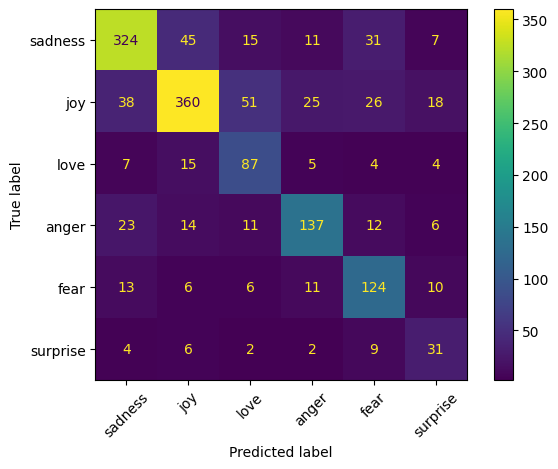

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    all_true,
    all_preds,
    display_labels=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'],
    xticks_rotation=45
)
plt.tight_layout()
plt.show()

Матрица ошибок показывает, что модель достаточно хорошо распознаёт все шесть эмоций. Наибольшее доля правильных прогнозов наблюдается для классов _sadness_, _joy_, _anger_ и _fear_. При этом основные ошибки возникают между эмоционально близкими категориями, что так же ожидаемо и согласуется со здравым смыслом: например, часть объектов класса _joy_ ошибочно относится к классам _love_ и _sadness_, а объекты класса _sadness_ иногда определяются как _joy_ или _fear_. Это объясняется тем, что в коротких текстах границы между отдельными эмоциональными состояниями часто оказываются размытыми даже в реальной жиззи.

Наиболее сложным для модели оказался класс _surprise_, поскольку удивление нередко выражается словами, пересекающимися с другими эмоциями. Несмотря на это, диагональные элементы матрицы существенно превосходят внедиагональные, что говорит о хорошем качестве классификации в целом.

### Вывод

В целом полученные результаты показывают, что модель Mamba успешно справляется с задачей классификации коротких текстов по шести эмоциям. Уровень точности оказался сопоставим с результатами, полученными ранее в предыдущем дз для модели Transformer на том же наборе данных, что подтверждает возможность  применения Mamba для задач анализа тональности и эмоциональной окраски текстов при меньшей вычислительной сложности по сравнению с Трансформером.